In [1]:
import os
import pandas as pd
import numpy as np
import torch
#torchvision, torchaudio installed
from tqdm import tqdm

In [2]:
print(torch.__version__)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built()) #checks if your current PyTorch installation was compiled with support for the MPS backend

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
torch.mps.empty_cache()

2.10.0
True
True
Using device: mps


In [3]:
import warnings
import nltk
SEED = 0
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
warnings.filterwarnings('ignore')
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jessie_guo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
from datasets import load_dataset
go_emotions = load_dataset("go_emotions")
print(go_emotions)
print(go_emotions['train'].features)

classes = go_emotions['train'].features['labels'].feature.names
print(f'\nClasses: {classes}')
len(classes)

train_data = pd.DataFrame(go_emotions['train'])
print(train_data)

counts = train_data['labels'].value_counts()
print(counts)
print(train_data['labels'])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}

Classes: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', '

In [5]:
#EKMAN MAPPING
import json

with open('ekman_mapping.json') as f:
    ekman_mapping = json.load(f)

ekman_mapping['neutral'] = ["neutral"]

ekman_classes = list(ekman_mapping.keys())

ekman2id = {e: i for i, e in enumerate(ekman_classes)}

ekman_num = {
    0: "anger", 1: "anger", 2: "anger",  # anger, annoyance, disapproval
    3: "disgust",                         # disgust
    4: "fear", 5: "fear",                 # fear, nervousness
    6: "joy", 7: "joy", 8: "joy", 9: "joy", 10: "joy", 11: "joy", 12: "joy", 13: "joy", 14: "joy", 15: "joy", 16: "joy", 17: "joy",  # joy etc.
    18: "sadness", 19: "sadness", 20: "sadness", 21: "sadness", 22: "sadness",  # sadness etc.
    23: "surprise", 24: "surprise", 25: "surprise", 26: "surprise", # surprise etc.
    27: "neutral"  # neutral
}

print(ekman_mapping)
print(ekman_classes)

def map_to_ekman(example):
    ekman_labels = set()

    for label in example["labels"]:
        ekman_category = ekman_num[label]
        ekman_labels.add(ekman_category)
        
    multi_hot = [0] * len(ekman_classes)
    for e in ekman_labels:
        multi_hot[ekman2id[e]] = 1

    example["labels"] = multi_hot
    return example
         
reduced_emotions = go_emotions.map(map_to_ekman)

train_data = pd.DataFrame(reduced_emotions['train'])
print(train_data)

counts = train_data['labels'].value_counts()
print(counts)

{'anger': ['anger', 'annoyance', 'disapproval'], 'disgust': ['disgust'], 'fear': ['fear', 'nervousness'], 'joy': ['joy', 'amusement', 'approval', 'excitement', 'gratitude', 'love', 'optimism', 'relief', 'pride', 'admiration', 'desire', 'caring'], 'sadness': ['sadness', 'disappointment', 'embarrassment', 'grief', 'remorse'], 'surprise': ['surprise', 'realization', 'confusion', 'curiosity'], 'neutral': ['neutral']}
['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']
                                                    text  \
0      My favourite food is anything I didn't have to...   
1      Now if he does off himself, everyone will thin...   
2                         WHY THE FUCK IS BAYLESS ISOING   
3                            To make her feel threatened   
4                                 Dirty Southern Wankers   
...                                                  ...   
43405  Added you mate well I’ve just got the bow and ...   
43406  Always thought that was fu

In [125]:
print(reduced_emotions['train'][0:8])

{'text': ["My favourite food is anything I didn't have to cook myself.", 'Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead', 'WHY THE FUCK IS BAYLESS ISOING', 'To make her feel threatened', 'Dirty Southern Wankers', "OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.", 'Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝', 'We need more boards and to create a bit more space for [NAME]. Then we’ll be good.'], 'labels': [[0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 1, 1, 0, 0]], 'id': ['eebbqej', 'ed00q6i', 'eezlygj', 'ed7ypvh', 'ed0bdzj', 'edvnz26', 'ee3b6wu', 'ef4qmod']}


In [132]:
#multi-class classification data processing
from transformers import AutoTokenizer, DataCollatorWithPadding

def onehot_to_class(example):
    example["labels"] = int(np.argmax(example["labels"]))
    return example

single_label_emotions = reduced_emotions.map(onehot_to_class)
print(single_label_emotions["train"][0]["labels"])

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_labelling(examples):
    tokenized = tokenizer(
        examples['text'],
        truncation = True,
        padding = "max_length",
        max_length = 128)
    return tokenized

tokenized_go_emotions = single_label_emotions.map(tokenize_labelling, 
                                        batched = True, 
                                        remove_columns = ["text"])

print(pd.DataFrame(tokenized_go_emotions['train']))

tokenized_go_emotions.set_format(
    type = "torch",
    columns = ["input_ids", "attention_mask", "labels"])

print(pd.DataFrame(tokenized_go_emotions['train']))
print(type(tokenized_go_emotions["train"][0]["labels"]))

Map: 100%|█████████| 5427/5427 [00:00<00:00, 72566.18 examples/s]


6


Map: 100%|█████████| 5427/5427 [00:00<00:00, 42974.85 examples/s]


       labels       id                                          input_ids  \
0           6  eebbqej  [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134...   
1           6  ed00q6i  [101, 2085, 2065, 2002, 2515, 2125, 2370, 1010...   
2           0  eezlygj  [101, 2339, 1996, 6616, 2003, 3016, 3238, 1116...   
3           3  ed7ypvh  [101, 2000, 2191, 2014, 2514, 5561, 102, 0, 0,...   
4           1  ed0bdzj  [101, 6530, 2670, 14071, 11451, 102, 0, 0, 0, ...   
...       ...      ...                                                ...   
43405       4  edsb738  [101, 2794, 2017, 6775, 2092, 1045, 1521, 2310...   
43406       3  ee7fdou  [101, 2467, 2245, 2008, 2001, 6057, 2021, 2003...   
43407       1  efgbhks  [101, 2054, 2024, 2017, 3331, 2055, 1029, 2505...   
43408       3  ed1naf8  [101, 2062, 2066, 1037, 18336, 1010, 2007, 791...   
43409       3  eecwmbq  [101, 5959, 1996, 4536, 999, 102, 0, 0, 0, 0, ...   

                                          token_type_ids  \
0      [0, 0, 0

In [6]:
#multi-label classification data processing all emotions included
from transformers import AutoTokenizer, DataCollatorWithPadding

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_and_process_labels(examples):
    # Tokenize the text
    tokenized = tokenizer(examples["text"], 
                                 padding="max_length", 
                                 truncation=True)

    # Process labels for multi-label classification (one-hot encoding)
    labels_batch = []
    for labels_list in examples["labels"]:
        one_hot_labels = np.zeros(len(classes), dtype=float)
        for label_idx in labels_list:
            one_hot_labels[label_idx] = 1.0
        labels_batch.append(one_hot_labels.tolist()) # Convert to list for dataset

    tokenized["labels"] = labels_batch
    return tokenized

tokenized_go_emotions = go_emotions.map(tokenize_and_process_labels, batched=True, remove_columns = ['text'])
print(pd.DataFrame(tokenized_go_emotions['train']))

tokenized_go_emotions.set_format(
    type = "torch",
    columns = ["input_ids", "attention_mask", "labels"])

print(pd.DataFrame(tokenized_go_emotions['train']))
print(type(tokenized_go_emotions["train"][0]["labels"]))

class CustomDataCollator:
    def __call__(self, batch):
        input_ids = torch.stack([x["input_ids"] for x in batch])
        attention_mask = torch.stack([x["attention_mask"] for x in batch])
        labels = torch.stack([x["labels"] for x in batch]).to(torch.float32)  # important!
        return {"input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels}

data_collator = CustomDataCollator()

                                                  labels       id  \
0      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  eebbqej   
1      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  ed00q6i   
2      [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  eezlygj   
3      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...  ed7ypvh   
4      [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  ed0bdzj   
...                                                  ...      ...   
43405  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  edsb738   
43406  [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...  ee7fdou   
43407  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  efgbhks   
43408  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...  ed1naf8   
43409  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  eecwmbq   

                                               input_ids  \
0      [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134...   
1      [101, 2085, 2065, 2002, 2515, 2125, 2370, 10

In [7]:
#multi-label classification data processing EKMAN CLASSES VERS.

from transformers import AutoTokenizer, DataCollatorWithPadding

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_labelling(examples):
    tokenized = tokenizer(
        examples['text'],
        truncation = True,
        padding = "max_length",
        max_length = 128)
    return tokenized

tokenized_go_emotions = reduced_emotions.map(tokenize_labelling, 
                                        batched = True, 
                                        remove_columns = ["text"])

print(pd.DataFrame(tokenized_go_emotions['train']))

tokenized_go_emotions.set_format(
    type = "torch",
    columns = ["input_ids", "attention_mask", "labels"])

print(pd.DataFrame(tokenized_go_emotions['train']))
print(type(tokenized_go_emotions["train"][0]["labels"]))

class CustomDataCollator:
    def __call__(self, batch):
        input_ids = torch.stack([x["input_ids"] for x in batch])
        attention_mask = torch.stack([x["attention_mask"] for x in batch])
        labels = torch.stack([x["labels"] for x in batch]).to(torch.float32)  # important!
        return {"input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels}

data_collator = CustomDataCollator()

#dynamically pads each batch to longest sequence in batch rather than padding every sequence - saves compute, memory
#mlm=False to avoid randomly masking tokens

                      labels       id  \
0      [0, 0, 0, 0, 0, 0, 1]  eebbqej   
1      [0, 0, 0, 0, 0, 0, 1]  ed00q6i   
2      [1, 0, 0, 0, 0, 0, 0]  eezlygj   
3      [0, 0, 0, 1, 0, 0, 0]  ed7ypvh   
4      [0, 1, 0, 0, 0, 0, 0]  ed0bdzj   
...                      ...      ...   
43405  [0, 0, 0, 0, 1, 0, 0]  edsb738   
43406  [0, 0, 0, 1, 0, 0, 0]  ee7fdou   
43407  [0, 1, 0, 0, 0, 0, 0]  efgbhks   
43408  [0, 0, 0, 1, 0, 0, 0]  ed1naf8   
43409  [0, 0, 0, 1, 0, 0, 0]  eecwmbq   

                                               input_ids  \
0      [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134...   
1      [101, 2085, 2065, 2002, 2515, 2125, 2370, 1010...   
2      [101, 2339, 1996, 6616, 2003, 3016, 3238, 1116...   
3      [101, 2000, 2191, 2014, 2514, 5561, 102, 0, 0,...   
4      [101, 6530, 2670, 14071, 11451, 102, 0, 0, 0, ...   
...                                                  ...   
43405  [101, 2794, 2017, 6775, 2092, 1045, 1521, 2310...   
43406  [101, 2467, 2245, 20

In [10]:
#Weights adjusted
y_train = np.array(tokenized_go_emotions["train"]["labels"])
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
pos_weight = neg_counts/pos_counts
pos_weight = torch.tensor(pos_weight, dtype = torch.float)
print(pos_weight)

tensor([ 4.4804, 16.5749,  9.9594,  2.2568,  7.7839, 13.3837,  2.0530])


In [ ]:
#Weights adjusted
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

class WeightedTrainer(Trainer): #creates new class inheriting from Trainer
    def __init__(self, *args, pos_weight=None, **kwargs): #*args passes any number of positional arguments, **kwargs pass any number of keyword (named) arguments. 
        super().__init__(*args, **kwargs) #calls original Trainer
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs): #rewrites the fn in Trainer
        labels = inputs.pop("labels").float() #removes target answer from inputs dict, need to reserve for validation
        outputs = model(**inputs)
        logits = outputs.logits #raw scores model produces before turned into probabilities

        loss_fct = nn.BCEWithLogitsLoss( #stand. loss for multi-labelling
            pos_weight = self.pos_weight.to(logits.device) #if rare label missed, multiply penalty by pos_weight, .to ensures weights moved to same loc as model
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss #in case Trainer needs predictions for eval metrics

In [134]:
#multi-class classification 
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model_1 = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, 
                                                             num_labels = len(ekman_classes), #len(classes),  
                                                             problem_type = "single_label_classification") #load the weights in saved dtype. Without, doubles memory usage if weights originally torch.bfloat16
model_1.to(device)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support, hamming_loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    predictions = logits.argmax(axis=-1)  # Get the predicted class labels

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    f1_micro = f1_score(labels, predictions, average = "micro", zero_division = 0)
    f1_macro = f1_score(labels, predictions, average = "macro", zero_division = 0)
    precision_micro = precision_score(labels, predictions, average="micro", zero_division=0)
    recall_micro = recall_score(labels, predictions, average="micro", zero_division=0)
    precision_macro = precision_score(labels, predictions, average="macro", zero_division=0)
    recall_macro = recall_score(labels, predictions, average="macro", zero_division=0)

    return {
        'f1_weighted': f1_weighted,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
    }
    
training_args = TrainingArguments(
    output_dir = "distilbert_finetuned-goemotions",
    num_train_epochs = 10,
    per_device_train_batch_size = 32,
    gradient_accumulation_steps = 4, #accumulate gradients across several batches and update once as opposed to updating weights every batch, simulates training with large batch size w/o storing, saves memory but slower training
    #gradient_checkpointing=True, #recomputes intermediate activations during forward pass as opposed to storing - extra computation but saves memory
    fp16 = False, #bf16 for fast mixed precision training, fp16 false for mps
    learning_rate = 2e-5, #initial lr
    logging_steps = 100, #controls how frequently to update + return loss
    eval_strategy = "epoch", #when to evaluate a model during training
    save_strategy = "epoch", #when to save
    weight_decay = 0.01, #L2 regularisation, helps prevent model from overfitting by discouraging large weights - uses AdamW, independent of weight updates --> better training stability
    metric_for_best_model = 'eval_f1_weighted',
    greater_is_better = True,
    load_best_model_at_end = True,
    save_total_limit = 2
)

trainer = Trainer(
    model = model_1,
    args = training_args,
    train_dataset = tokenized_go_emotions["train"],
    eval_dataset = tokenized_go_emotions["validation"],
    processing_class = tokenizer,
    compute_metrics = compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    #pos_weight = pos_weight
)

trainer.train()

trainer.save_model("distilbert_finetuned-goemotions-final")
tokenizer.save_pretrained("distilbert_finetuned-goemotions-final")

Loading weights: 100%|███████| 100/100 [00:00<00:00, 9134.73it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Weighted,Precision Weighted,Recall Weighted,F1 Micro,Precision Micro,Recall Micro,F1 Macro,Precision Macro,Recall Macro
1,4.652582,1.092187,0.602374,0.602206,0.617582,0.617582,0.617582,0.617582,0.520981,0.560146,0.516823
2,4.167807,1.061365,0.618014,0.616311,0.621821,0.621821,0.621821,0.621821,0.556697,0.566059,0.553050
3,3.805074,1.048998,0.622294,0.620258,0.625691,0.625691,0.625691,0.625691,0.563288,0.570078,0.558737
4,3.576273,1.063512,0.614404,0.614696,0.622558,0.622558,0.622558,0.622558,0.550796,0.573529,0.541855
5,3.220984,1.094478,0.613375,0.613054,0.616845,0.616845,0.616845,0.616845,0.552405,0.555058,0.553646
6,2.955019,1.132031,0.613073,0.612043,0.616661,0.616661,0.616661,0.616661,0.553432,0.554582,0.556479


Writing model shards: 100%|████████| 1/1 [00:00<00:00,  5.38it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|████████| 1/1 [00:00<00:00,  4.64it/s]


('distilbert_finetuned-goemotions-final/tokenizer_config.json',
 'distilbert_finetuned-goemotions-final/tokenizer.json')

In [169]:
from sklearn.metrics import f1_score, precision_score, recall_score

def find_best_threshold(logits, labels):
    probs = 1/(1 + np.exp(-logits))
    best_t_micro = 0.5
    best_t_macro = 0.5
    best_t_weighted = 0.5
    best_f1_micro = 0
    best_f1_macro = 0
    best_f1_weighted = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs > t).astype(int)
        f1_micro = f1_score(labels, preds, average = "micro", zero_division = 0)
        f1_macro = f1_score(labels, preds, average = "macro", zero_division = 0)
        f1_weighted = f1_score(labels, preds, average = "weighted", zero_division = 0)
        if f1_micro > best_f1_micro:
            best_f1_micro = f1_micro
            best_t_micro = t
        if f1_macro > best_f1_macro:
            best_f1_macro = f1_macro
            best_t_macro = t
        if f1_weighted > best_f1_weighted:
            best_f1_weighted = f1_weighted
            best_t_weighted = t

    return best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted

In [170]:
#multi-label classification

import torch.nn as nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model_1 = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, 
                                                             num_labels = len(ekman_classes), #len(classes),  
                                                             problem_type = "multi_label_classification") #load the weights in saved dtype. Without, doubles memory usage if weights originally torch.bfloat16
model_1.to(device)

from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_fscore_support, hamming_loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    best_t_macro, best_t_micro, best_t_weighted, best_f1_macro, best_f1_micro, best_f1_weighted = find_best_threshold(logits, labels)

    probs = 1 / (1 + np.exp(-logits))
    
    predictions = (probs > best_t_weighted).astype(int)  # Get the predicted class labels
    
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    f1_micro = f1_score(labels, predictions, average = "micro", zero_division = 0)
    f1_macro = f1_score(labels, predictions, average = "macro", zero_division = 0)
    precision_micro = precision_score(labels, predictions, average="micro", zero_division=0)
    recall_micro = recall_score(labels, predictions, average="micro", zero_division=0)
    precision_macro = precision_score(labels, predictions, average="macro", zero_division=0)
    recall_macro = recall_score(labels, predictions, average="macro", zero_division=0)
    hamming_loss_score = hamming_loss(labels, predictions)

    return {
        'f1_weighted': f1_weighted,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'hamming_loss_score': hamming_loss_score
    }
    
training_args = TrainingArguments(
    output_dir = "distilbert_finetuned-goemotions2",
    num_train_epochs = 10,
    per_device_train_batch_size = 32,
    gradient_accumulation_steps = 4, #accumulate gradients across several batches and update once as opposed to updating weights every batch, simulates training with large batch size w/o storing, saves memory but slower training
    #gradient_checkpointing=True, #recomputes intermediate activations during forward pass as opposed to storing - extra computation but saves memory
    fp16 = False, #bf16 for fast mixed precision training, fp16 false for mps
    learning_rate = 2e-5, #initial lr
    logging_steps = 100, #controls how frequently to update + return loss
    eval_strategy = "epoch", #when to evaluate a model during training
    save_strategy = "epoch", #when to save
    weight_decay = 0.01, #L2 regularisation, helps prevent model from overfitting by discouraging large weights - uses AdamW, independent of weight updates --> better training stability
    metric_for_best_model = 'eval_f1_weighted',
    greater_is_better = True,
    load_best_model_at_end = True,
    save_total_limit = 2
)

trainer2 = Trainer(
    model = model_1,
    args = training_args,
    train_dataset = tokenized_go_emotions["train"],
    eval_dataset = tokenized_go_emotions["validation"],
    processing_class = tokenizer,
    data_collator = data_collator,
    compute_metrics = compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    #pos_weight = pos_weight
)

trainer2.train()

trainer2.save_model("distilbert_finetuned-goemotions-final2")
tokenizer.save_pretrained("distilbert_finetuned-goemotions-final2")

Loading weights: 100%|███████| 100/100 [00:00<00:00, 8233.17it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Weighted,Precision Weighted,Recall Weighted,F1 Micro,Precision Micro,Recall Micro,F1 Macro,Precision Macro,Recall Macro,Hamming Loss Score
1,1.208114,0.285317,0.609622,0.588701,0.660857,0.624367,0.591696,0.660857,0.540382,0.563893,0.556062,0.130930
2,1.073607,0.269752,0.639500,0.607489,0.681804,0.642362,0.607234,0.681804,0.593172,0.579385,0.613919,0.125007
3,0.993569,0.265415,0.645940,0.611681,0.686441,0.648980,0.615396,0.686441,0.597747,0.579342,0.620014,0.122268
4,0.933289,0.269489,0.642724,0.608870,0.687720,0.648327,0.613202,0.687720,0.592495,0.578703,0.615655,0.122848
5,0.858337,0.278121,0.639556,0.625366,0.655900,0.639838,0.624543,0.655900,0.592279,0.573605,0.613605,0.121584
6,0.796504,0.283033,0.640139,0.585553,0.707067,0.640637,0.585618,0.707067,0.591605,0.540487,0.654987,0.130615


Writing model shards: 100%|████████| 1/1 [00:00<00:00,  4.56it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Writing model shards: 100%|████████| 1/1 [00:00<00:00,  6.56it/s]


('distilbert_finetuned-goemotions-final2/tokenizer_config.json',
 'distilbert_finetuned-goemotions-final2/tokenizer.json')

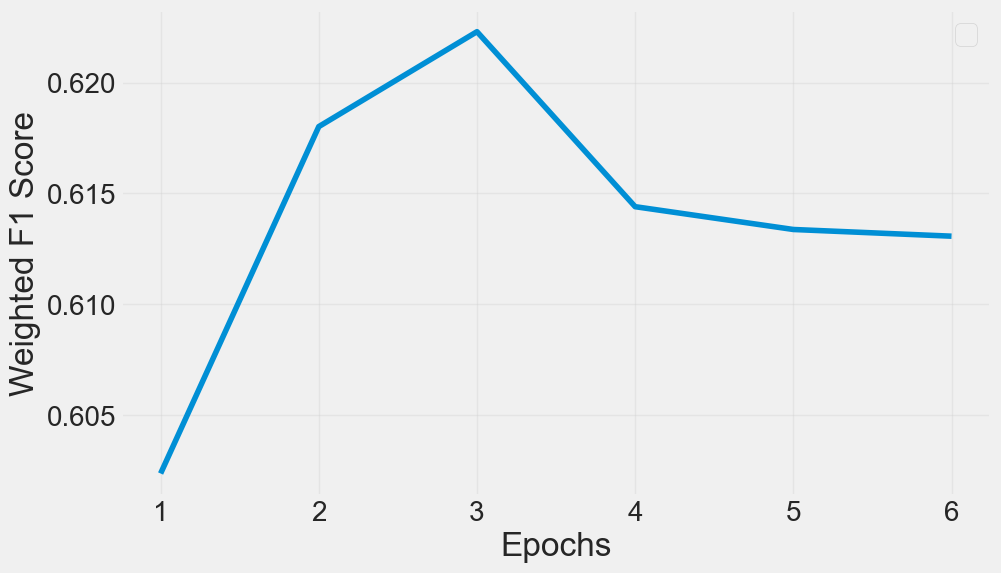

In [171]:
#Training and Validation Loss, Weighted_F1 Curves
import matplotlib.pyplot as plt
import pandas as pd

history = trainer.state.log_history
df = pd.DataFrame(history)

train_df = df[df['loss'].notna()]
eval_df = df[df['eval_loss'].notna()]
weighted_f1_df = df[df['eval_f1_weighted'].notna()]

plt.figure(figsize=(10, 6))

plt.plot(train_df['epoch'], train_df['loss'], label='Training Loss')
plt.plot(eval_df['epoch'], eval_df['eval_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Training and Validation Loss")
plt.clf()

plt.plot(weighted_f1_df['epoch'], weighted_f1_df['eval_f1_weighted'])
plt.xlabel('Epochs')
plt.ylabel('Weighted F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Weighted F1 Score")


In [94]:
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, EarlyStoppingCallback

SAVE_OUTPUT = "distilbert_finetuned-goemotions-final"

def save_to_device(SAVE_OUTPUT):
    model_new = AutoModelForSequenceClassification.from_pretrained(SAVE_OUTPUT)
    tokenizer_new = AutoTokenizer.from_pretrained(SAVE_OUTPUT)
    return model_new, tokenizer_new

model_new, tokenizer_new = save_to_device(SAVE_OUTPUT)

model_new.to(device)
model_new.eval()

Loading weights: 100%|█████████| 104/104 [00:00<00:00, 2849.93it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [95]:
from torch.utils.data import Dataset
class CustomDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.dataframe = dataframe
        self.texts = dataframe['text']
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts.iloc[index])
        text = " ".join(text.split())
        inputs = self.tokenizer(
            text,
            None,
            add_special_tokens=True,  # Add special tokens
            max_length=self.max_len,
            padding='max_length',  # Pad to max_length
            return_token_type_ids=True,
            return_tensors='pt',  # Return PyTorch tensors
            truncation=True  # Truncate sequences longer than max_length
        )
        
        input_ids = inputs['input_ids'].squeeze(0)  # Remove the added batch dimension
        attention_mask = inputs['attention_mask'].squeeze(0)  # Remove the added batch dimension
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
        }

In [98]:
def test(test_loader):
    model_new.eval()
    all_outputs = []
    with torch.no_grad():
        for data in test_loader:
            input_ids = data['input_ids'].to(device) #, dtype=torch.long)
            attention_mask = data['attention_mask'].to(device) #, dtype=torch.long)
            outputs = model_new(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs.logits

            if PROBLEM_TYPE == "multi_label_classification":
                probs = torch.sigmoid(logits)
                all_outputs.extend(probs.cpu().numpy().tolist())
            elif PROBLEM_TYPE == "single_label_classification":
                probs = torch.softmax(logits, dim = -1)
                predictions = torch.argmax(probs, dim = -1)
                all_outputs.extend(predictions.cpu().numpy().tolist())  
    
    return all_outputs

In [46]:
lengths = [len(tokenizer_new.encode(text)) for text in go_emotions['train']['text']]
print(max(lengths)) #max token count across all texts
print("95th percentile:", np.percentile(lengths, 95)) #95% of samples contain 34 tokens or fewer 

MAX_LEN = 128

316
95th percentile: 34.0


In [135]:
texts_path = 'Data/Georgian/GeorgianNews/'
poem_names = []
sources = ['orig/', 'en/', 'ggl/', 'gem/', 'gpt/']
#ge_1tv_csv = texts_path + "ge/ge_original_1tv_news/combined_all_articles_ge.csv"
#ge_IPN_csv = texts_path + "ge/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv"

#df_1tv_ge = pd.read_csv(ge_1tv_csv)
#df_IPN_ge = pd.read_csv(ge_IPN_csv)

#df_ge = pd.concat([df_1tv_ge, df_IPN_ge], axis = 0)
#print(df_ge.head())
#print(df_ge.columns)

def combine_news(lang_1tv, lang_ipn):
    onetv_lang = pd.read_csv(lang_1tv)
    ipn_lang = pd.read_csv(lang_ipn)
    
    df_ge = pd.concat([onetv_lang, ipn_lang], axis = 0)
    print(df_ge.head())
    print(df_ge.columns)
    return df_ge

df_orig = combine_news(texts_path + "orig/ge_original_1tv_news/combined_all_articles_ge.csv", texts_path + "orig/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv")
df_en = combine_news(texts_path + "en/eng_expert_1tv_news/combined_all_articles_eng.csv", texts_path + "en/eng_expert_IPN_news/IPN_news_combined_master_eng_renamed.csv")
df_gem = combine_news(texts_path + "gem/gem_1tv_news/combined_all_articles_gem.csv", texts_path + "gem/gem_IPN_news/IPN_news_combined_master_gem_renamed.csv")
df_ggl = combine_news(texts_path + "ggl/ggl_1tv_news/combined_all_articles_ggl.csv", texts_path + "ggl/ggl_IPN_news/IPN_news_combined_master_ggl_renamed.csv")
df_gpt = combine_news(texts_path + "gpt/gpt_1tv_news/combined_all_articles_gpt.csv", texts_path + "gpt/gpt_IPN_news/IPN_news_combined_master_gpt_renamed.csv")
article_names = sorted(df_orig["Source File"].unique())
print(article_names)
#print(len(article_names))
#print(df_en)

                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  ვახტანგ ცინცაძე - აზიის განვითარების ბანკის ან...  
1  აზიის განვითარების ბანკმა აზიის ეკონომიკური პე...  
2  როგორც მინისტრის მოადგილემ აღნიშნა, აზიის განვ...  
3  ვახტანგ ცინცაძის განცხადებით,  2026 წელს აზიის...  
4  „აზიის განვითარების ბანკი ასევე ხაზგასმით აღნი...  
Index(['Source File', 'Content'], dtype='object')
                      Source File  \
0  01_deputy_economy_minister.csv   
1  01_deputy_economy_minister.csv   
2  01_deputy_economy_minister.csv   
3  01_deputy_economy_minister.csv   
4  01_deputy_economy_minister.csv   

                                             Content  
0  Deputy Economy Minister: ADB highlights Georgi...  
1  “The Asian Development Bank (ADB) has publishe...  
2  The De

In [99]:
from torch.utils.data import DataLoader
PROBLEM_TYPE = "multi_label_classification"
def text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt):
    source_dfs = {
        "orig/": df_orig,
        "en/": df_en,
        "ggl/": df_ggl,
        "gem/": df_gem,
        "gpt/": df_gpt
    }
    
    output_base = OUTPUT_BASE
    os.makedirs(output_base, exist_ok = True)
    for source, source_df in source_dfs.items():
        output_dir = os.path.join(output_base, source)
        os.makedirs(output_dir, exist_ok = True)
        
        for article in article_names:
            article_rows = source_df[source_df["Source File"] == article]
            if "Translated Content" in source_df.columns:
                article_text = (
                    article_rows["Translated Content"]
                    .fillna("")
                    .astype(str)
                    .str.strip()
                    .tolist()
                )
    
            else:
                article_text = (
                    article_rows["Content"]
                    .fillna("")
                    .astype(str)
                    .str.strip()
                    .tolist()
                )
            article_text = [text for text in article_text if text != ""]
    
            article_df = pd.DataFrame(article_text, columns=['text'])
    
            test_dataset = CustomDataset(article_df, tokenizer, MAX_LEN)
            test_params = {'batch_size': 1, 'shuffle': False}
            test_loader = DataLoader(test_dataset, **test_params)
            
            test_outputs = np.array(test(test_loader))
    
            test_outputs = (test_outputs >= 0.3).astype(int)
            for label in ekman_classes:
                article_df[label] = 0
    
            for i in range(len(test_outputs)):
                for j, label in enumerate(ekman_classes):
                    article_df.at[i, label] = test_outputs[i][j]
    
            output_file = os.path.join(output_dir, article)
            article_df.to_csv(output_file, index = False)
    
            print(f"Saved: {output_file}")

text_df('results/news/sentiment/', article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)


Saved: results/news/sentiment/orig/01_deputy_economy_minister.csv
Saved: results/news/sentiment/orig/01_ge_Irakli_Kobakhidze.csv
Saved: results/news/sentiment/orig/02_ge_Giorgi_Sharashidze.csv
Saved: results/news/sentiment/orig/02_georgia_to_recognise.csv
Saved: results/news/sentiment/orig/03_ge_Mariam_Kvrivishvili.csv
Saved: results/news/sentiment/orig/03_good_friday.csv
Saved: results/news/sentiment/orig/04_ge_Maka_Botchorishvili.csv
Saved: results/news/sentiment/orig/04_metropolitan_shio.csv
Saved: results/news/sentiment/orig/05_ge_Archpriest_Andria.csv
Saved: results/news/sentiment/orig/05_people_power.csv
Saved: results/news/sentiment/orig/06_ge_Armaz_Akhvlediani.csv
Saved: results/news/sentiment/orig/06_tbilisi_offers_free_metro.csv
Saved: results/news/sentiment/orig/07_ge_Giorgi_Sharashidze.csv
Saved: results/news/sentiment/orig/07_trailers_and_semi-trailers.csv
Saved: results/news/sentiment/orig/08_ge_Classification_wine.csv
Saved: results/news/sentiment/orig/08_vehicle_movemen

In [104]:
def all_article_dataframe(source, ekman_classes, OUTPUT_BASE):
    total_counts = {label: 0 for label in ekman_classes}
    
    for article in article_names:
        df = pd.read_csv(OUTPUT_BASE + source + article)
        
        if 'text' in df.columns:
            df = df.drop(columns = ['text'])
        
        # sum counts directly (since labels are 0/1)  
        for label in ekman_classes:
            if label in df.columns:
                total_counts[label] += df[label].sum()

    new_df = pd.DataFrame({
        "Sentiment": list(total_counts.keys()),
        "Count": list(total_counts.values())
    })

    return new_df

  Sentiment  Count  Count  Count  Count
0     anger     95    100    101    101
1   disgust     67     63     61     66
2      fear    194    194    194    196
3       joy    210    210    210    210
4   sadness    165    162    166    163
5  surprise     14     12     13     15
6   neutral    210    210    210    210
  Sentiment  English  Google  Gemini  ChatGPT
0     anger       95     100     101      101
1   disgust       67      63      61       66
2      fear      194     194     194      196
3       joy      210     210     210      210
4   sadness      165     162     166      163
5  surprise       14      12      13       15
6   neutral      210     210     210      210
0   Models anger disgust fear  joy sadness surprise neutral
0  English    95      67  194  210     165       14     210
1   Google   100      63  194  210     162       12     210
2   Gemini   101      61  194  210     166       13     210
3  ChatGPT   101      66  196  210     163       15     210
Index(['Mode

TypeError: move_legend() missing 1 required positional argument: 'loc'

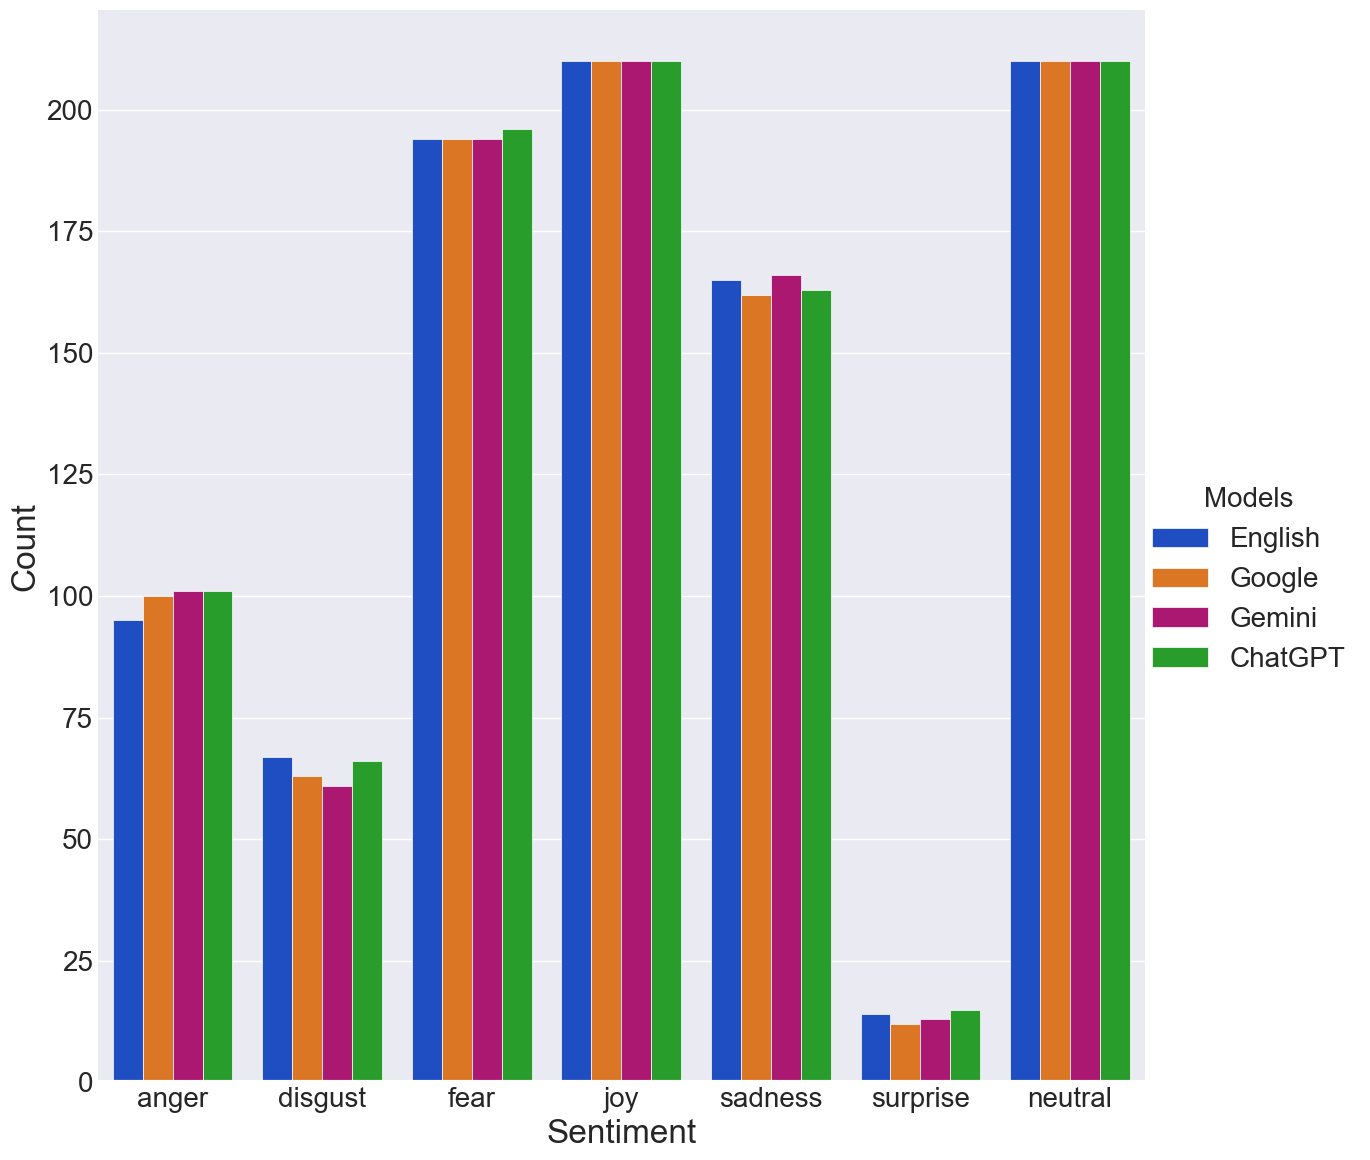

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt
def sentiment_bar(OUTPUT_BASE, SAVEFIG):
    output_base = OUTPUT_BASE
    output_graphs = os.path.join(output_base, 'graphs')
    os.makedirs(output_graphs, exist_ok = True)
    
    en_sentiment = all_article_dataframe('en/', ekman_classes, OUTPUT_BASE)
    ggl_sentiment = all_article_dataframe('ggl/', ekman_classes, OUTPUT_BASE)
    gem_sentiment = all_article_dataframe('gem/', ekman_classes, OUTPUT_BASE)
    gpt_sentiment = all_article_dataframe('gpt/', ekman_classes, OUTPUT_BASE)
    
    df_new = pd.concat(
        [
            en_sentiment, 
            ggl_sentiment['Count'], 
            gem_sentiment['Count'], 
            gpt_sentiment['Count'],
        ],
        axis=1
    )
    
    print(df_new)
    
    df_new.columns = ['Sentiment', 'English', 'Google', 'Gemini', 'ChatGPT']
    print(df_new)
    
    df_sentiment_counts = df_new.T.reset_index()
    df_sentiment_counts.columns = df_sentiment_counts.iloc[0, ]
    df_sentiment_counts = df_sentiment_counts.iloc[1:, ].reset_index(drop=True)
    df_sentiment_counts = df_sentiment_counts.rename(columns={'Sentiment': 'Models'})
    
    print(df_sentiment_counts.head())
    print(df_sentiment_counts.columns)
    
    df_new = pd.melt(df_new, id_vars="Sentiment", var_name="Models", value_name="Count")
    print(df_new)
    colors = ["blue", "orange", "magenta", "green"]  
    myPalette = sns.xkcd_palette(colors)
    
    sns.set_style("darkgrid")
    g = sns.catplot(x='Sentiment', y='Count', hue='Models', data=df_new, kind='bar', height=12, palette=myPalette, legend=True)
    g.despine(left=True)
    sns.move_legend(g, prop={"size": 20}, title='')
    plt.ylabel('Count', labelpad=30, fontsize=30)
    plt.xlabel(' ')
    #plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) #{tick values, add commas for thousands operator, round to 0 decimal places}
    plt.yticks(fontsize= 25)
    plt.xticks(fontsize = 25)
    plt.xticks(rotation=90)
    plt.savefig(SAVEFIG)

sentiment_bar('results/news/sentiment/', 'results/news/sentiment/graphs/sentiment_all_ru.png')

In [106]:
sentiment_polarity = { #find literature where go emotions using ekman mapping and the polarities used
    'anger': -2,
    'disgust': -1,
    'fear': -2,
    'joy':  2,
    'sadness': -1,
    'surprise': 1,
    'neutral': 0,
}

In [52]:
%matplotlib inline
sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [107]:
def plot_polarity_vs_verse(article, model_paths, model_labels, sentiment_polarity, output_path):
    plt.figure(figsize = (14, 6))

    for path, label in zip(model_paths, model_labels):
        df = pd.read_csv(path + article)
        polarity_scores = []
        for _, row in df.iterrows():
            polarity = sum(
                row.get(emotion, 0) * weight for emotion, weight in sentiment_polarity.items()
            )
            polarity_scores.append(polarity)
            
        paragraphs = np.arange(1, len(polarity_scores) + 1)
        
        plt.plot(paragraphs, polarity_scores, label = label)

    plt.ylabel('Sentiment Polarity')#, labelpad=40, fontsize=30)
    plt.xlabel('Paragraph Number')#, labelpad=30, fontsize=30)
    plt.title(f'Polarity vs. Paragraph for {article[:2]}')
    
    plt.legend(title = 'Models')
    plt.grid(True)
    plt.tight_layout()
    
    plt.show()
    plt.savefig(output_path)


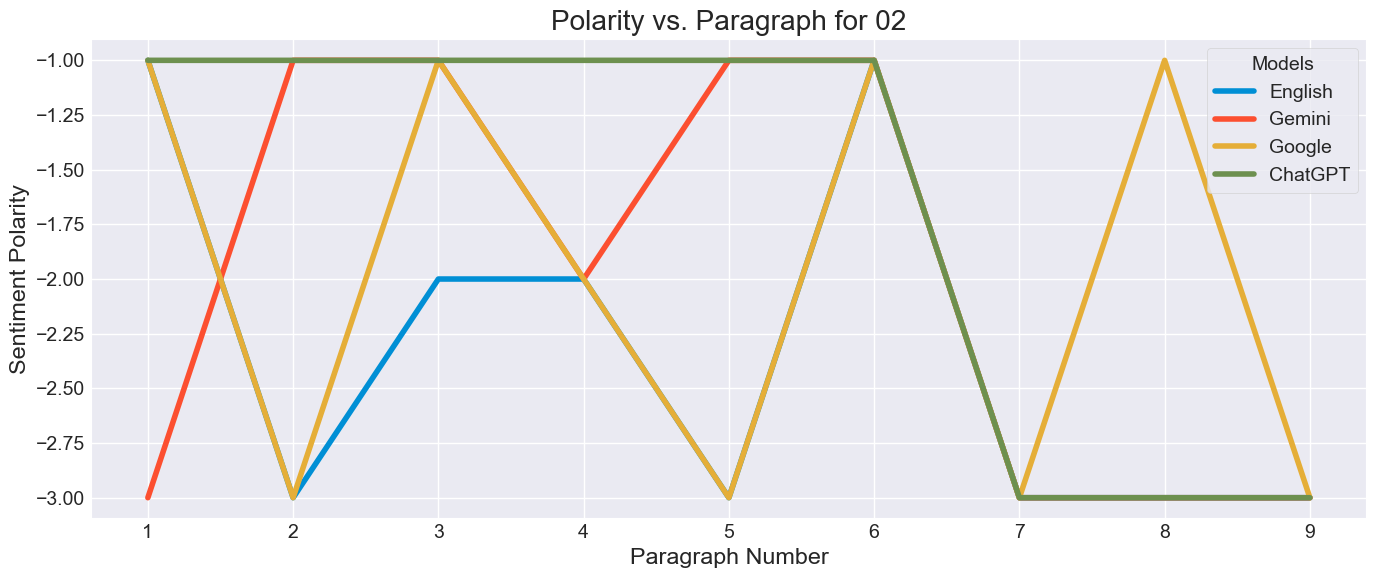

<Figure size 640x480 with 0 Axes>

In [108]:
article = '02_ge_Giorgi_Sharashidze.csv'

model_paths = [
    'results/news/sentiment/en/', #'results_bul/news/sentiment/'
    'results/news/sentiment/gem/', #'results_bul/news/sentiment/'
    'results/news/sentiment/ggl/', #'results_bul/news/sentiment/'
    'results/news/sentiment/gpt/', #'results_bul/news/sentiment/'
]

model_labels = ['English', 'Gemini', 'Google', 'ChatGPT']
#plt.savefig('results/poems/graphs/hewitt_polarity.png')
plot_polarity_vs_verse(
    article, model_paths, model_labels, sentiment_polarity, output_path = f'results/news/sentiment/graphs/{model_labels}_polarity.png'
) #'results_bul/news/sentiment/'

In [109]:
import re
import gensim 
import nltk
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
newStopWords = []
stop_words.extend(newStopWords)


def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(str(text)) if word not in stop_words] for text in texts]
    #list without stopwords

def tokenize(texts):
    for text in texts:
        yield(gensim.utils.simple_preprocess(str(text), deacc=True))
        #tokenized, without punctuation, accents

def preprocessing(df):
    df = df.copy()
    df['text'] = df['text'].str.lower()                                                      # Convert to lowercase
    df['text'] = df['text'].str.replace(r'[^a-zA-Z#]', ' ', regex=True) #     # keep letters and spaces only
    df['text'] = df['text'].apply(lambda x:' '.join([w for w in x.split() if len(w)>2]))     # Remove short words
    df['tokens'] = list(tokenize(df['text']))
    df['tokens_no_stop'] = remove_stopwords(df['text'])
    df['tokens_no_stop_joined'] = df['tokens_no_stop'].apply(lambda x: ' '.join(x) )
    
    return df

def retrieve_text(df):
    doc = '. '.join(df['tokens_no_stop_joined'])
    return doc

def ngrams_series_func(data, n):
    wordList = re.sub("[^\w]", " ",  data).split() #replace non-words with spaces
    ngrams_series = (pd.Series(nltk.ngrams(wordList, n)).value_counts())[:5] #top 5 most frequent
    return ngrams_series

In [56]:
from matplotlib import cm
from matplotlib.ticker import FuncFormatter

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
barcolors = ['#87B88C','#9ED2A1','#E7E8CB','#48A0C9','#2A58A1','#2E8B55','#DF3659','Grey']
barstyle = {"edgecolor":"black", "linewidth": 1}

In [110]:
def topic(source, OUTPUT_BASE, article_names):
    topic_df = pd.read_csv(OUTPUT_BASE + source + article_names[0])

    #print(topic_df)
    
    for article in article_names[1:]:
        df = pd.read_csv(OUTPUT_BASE + source + article) #'results_bul/news/sentiment/'
        topic_df = pd.concat([topic_df, df], axis=0, ignore_index=True)
    
    return topic_df

In [111]:
from matplotlib.ticker import MaxNLocator

def ngrams_graphs(text, translation):  
    output_ngrams = os.path.join(output_graphs, 'ngrams')
    os.makedirs(output_ngrams, exist_ok = True)
    
    bigram1 = ngrams_series_func(text, 2)
    trigram1 = ngrams_series_func(text, 3)
    ngram1 = pd.concat([bigram1, trigram1])
    
    plt.rcParams.update({'font.size': 20})
    fig, ax=plt.subplots(1,1, figsize=(8,4))
    
    barh_ax = ax
    
    ngram1[::-1].plot.barh(ax=barh_ax, color='magenta', **barstyle)
    barh_ax.yaxis.set_label_position("left")
    barh_ax.xaxis.tick_top()
    barh_ax.xaxis.set_label_position("bottom")
    barh_ax.set_xlim(barh_ax.get_xlim()[::-1])
    barh_ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    barh_ax.set_xlabel(translation)
    barh_ax.set_ylabel('', fontsize=50)
    plt.tight_layout()
    plt.savefig(f'results/news/sentiment/graphs/ngrams/{translation}.png', facecolor='white')


0
Empty DataFrame
Columns: [text, anger, disgust, fear, joy, sadness, surprise, neutral]
Index: []


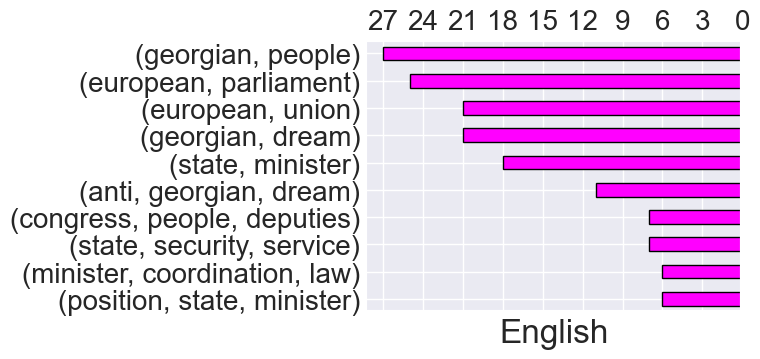

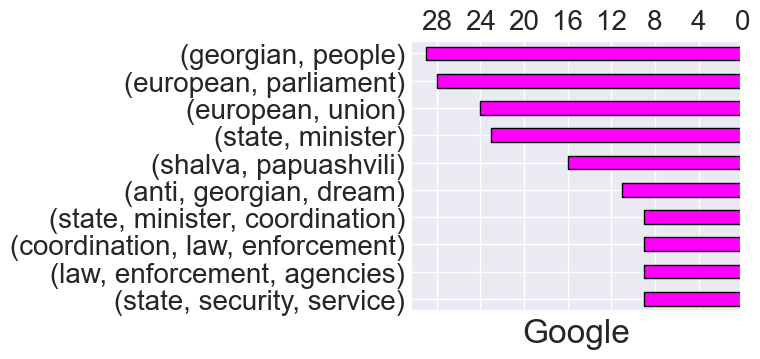

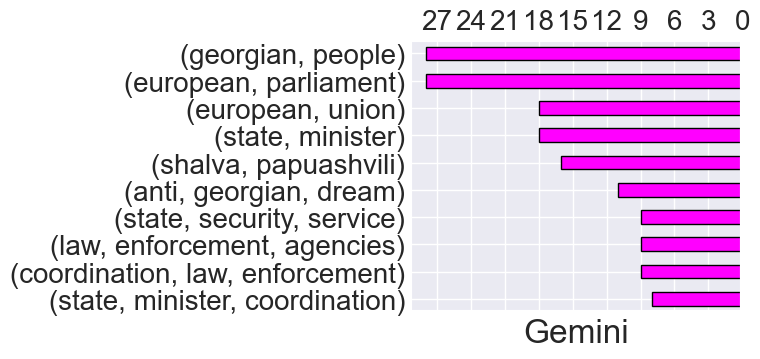

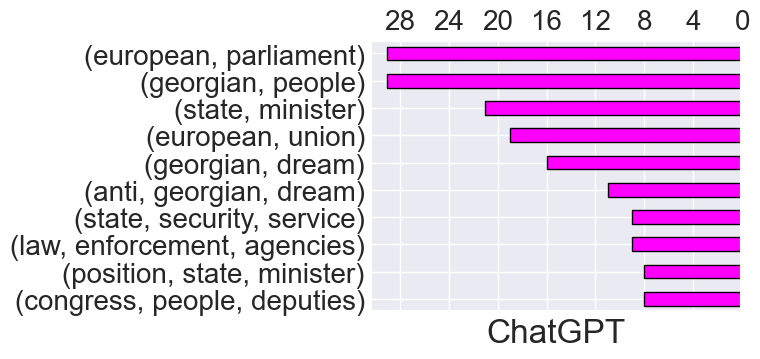

In [113]:
#Georgian News
OUTPUT_BASE = "results/news/sentiment/"
topic_df = topic('en/', OUTPUT_BASE, article_names)
print(topic_df["text"].isna().sum())
print(topic_df[topic_df["text"].isna()].head(20))

topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'English')

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google')

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini')

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT')

In [114]:
#Bulgarian News

texts_path = 'Data/Bulgarian/BulgarianNews/'
#ge_1tv_csv = texts_path + "ge/ge_original_1tv_news/combined_all_articles_ge.csv"
#ge_IPN_csv = texts_path + "ge/ge_original_IPN_news/IPN_news_combined_master_ge_renamed.csv"

#df_1tv_ge = pd.read_csv(ge_1tv_csv)
#df_IPN_ge = pd.read_csv(ge_IPN_csv)

#df_ge = pd.concat([df_1tv_ge, df_IPN_ge], axis = 0)
#print(df_ge.head())
#print(df_ge.columns)

In [122]:
file_paths = ["orig/BTA_news_combined_master_bul.csv", 
              "en/BTA_news_combined_master_eng.csv",
              "gem/BTA_news_combined_master_gem.csv",
              "ggl/BTA_news_combined_master_ggl.csv",
              "gpt/BTA_news_combined_master_gpt.csv"]

OUTPUT_BASE = 'results_bul/news/sentiment/'

def text_name(texts_path, file_paths):
    sources = ['orig/', 'en/', 'ggl/', 'gem/', 'gpt/']
    df_orig = pd.read_csv(texts_path + file_paths[0])
    df_en = pd.read_csv(texts_path + file_paths[1])
    df_gem = pd.read_csv(texts_path + file_paths[2])
    df_ggl = pd.read_csv(texts_path + file_paths[3])
    df_gpt = pd.read_csv(texts_path + file_paths[4])
    article_names = sorted(df_orig["Source File"].unique())
    print(article_names)
    print(len(article_names))
    return article_names, df_orig, df_en, df_ggl, df_gem, df_gpt

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)


['bul_Bulgaria_Driving_04.csv', 'bul_Bulgaria_Submits_08.csv', 'bul_Bulgarian_Airline_02.csv', 'bul_Bulgarian_Cultural_03.csv', 'bul_Bulgarian_Deputy_05.csv', 'bul_Dispute_Erupts_09.csv', 'bul_Mexico_Festival_07.csv', 'bul_Patriarch_Daniil_06.csv', 'bul_Political_Forces_01.csv']
9
Saved: results_bul/news/sentiment/orig/bul_Bulgaria_Driving_04.csv
Saved: results_bul/news/sentiment/orig/bul_Bulgaria_Submits_08.csv
Saved: results_bul/news/sentiment/orig/bul_Bulgarian_Airline_02.csv
Saved: results_bul/news/sentiment/orig/bul_Bulgarian_Cultural_03.csv
Saved: results_bul/news/sentiment/orig/bul_Bulgarian_Deputy_05.csv
Saved: results_bul/news/sentiment/orig/bul_Dispute_Erupts_09.csv
Saved: results_bul/news/sentiment/orig/bul_Mexico_Festival_07.csv
Saved: results_bul/news/sentiment/orig/bul_Patriarch_Daniil_06.csv
Saved: results_bul/news/sentiment/orig/bul_Political_Forces_01.csv
Saved: results_bul/news/sentiment/en/bul_Bulgaria_Driving_04.csv
Saved: results_bul/news/sentiment/en/bul_Bulgaria_

  Sentiment  Count  Count  Count  Count
0     anger     65     68     69     67
1   disgust      6      8      8      9
2      fear     80     79     78     77
3       joy     82     82     82     82
4   sadness     65     66     65     67
5  surprise      4      3      5      5
6   neutral     82     82     82     82
  Sentiment  English  Google  Gemini  ChatGPT
0     anger       65      68      69       67
1   disgust        6       8       8        9
2      fear       80      79      78       77
3       joy       82      82      82       82
4   sadness       65      66      65       67
5  surprise        4       3       5        5
6   neutral       82      82      82       82
0   Models anger disgust fear joy sadness surprise neutral
0  English    65       6   80  82      65        4      82
1   Google    68       8   79  82      66        3      82
2   Gemini    69       8   78  82      65        5      82
3  ChatGPT    67       9   77  82      67        5      82
Index(['Models', 

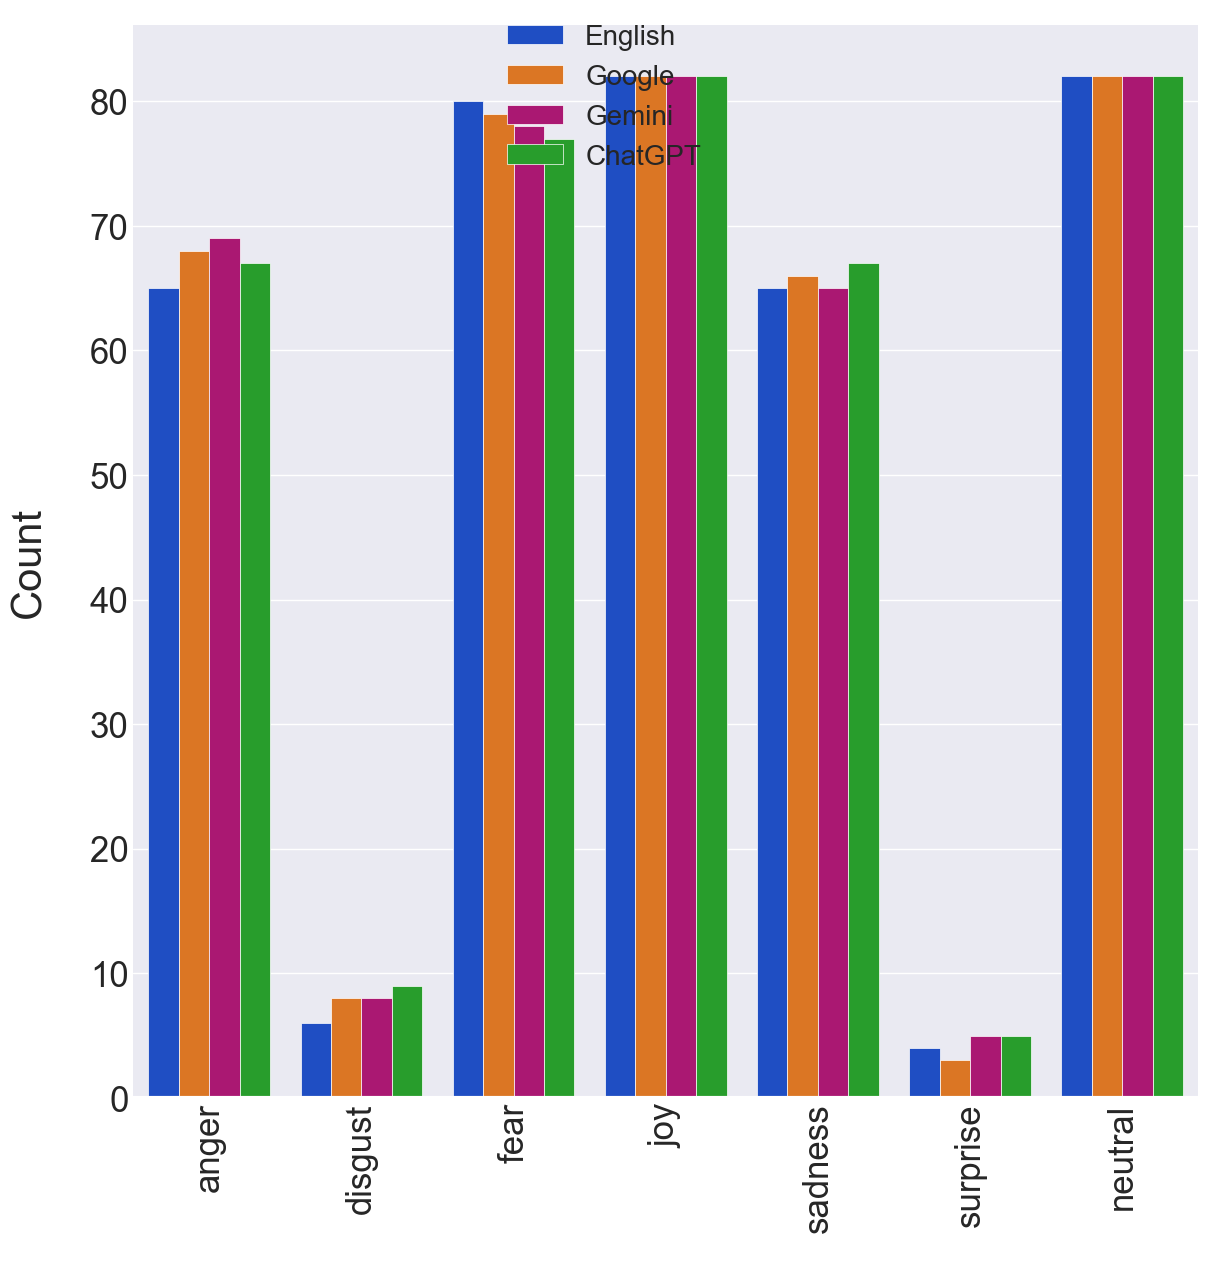

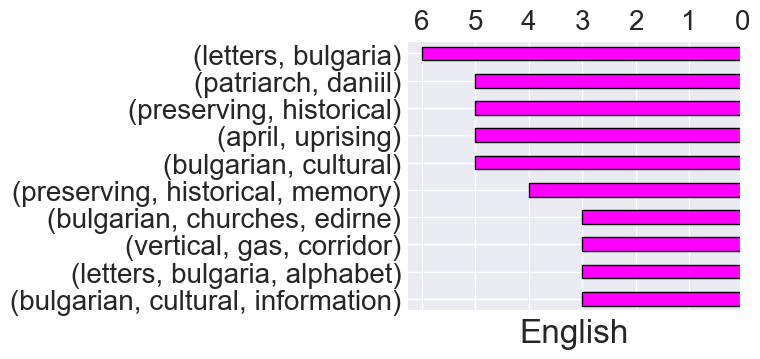

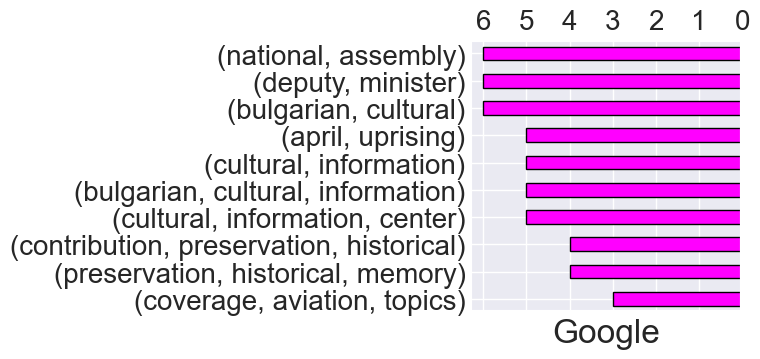

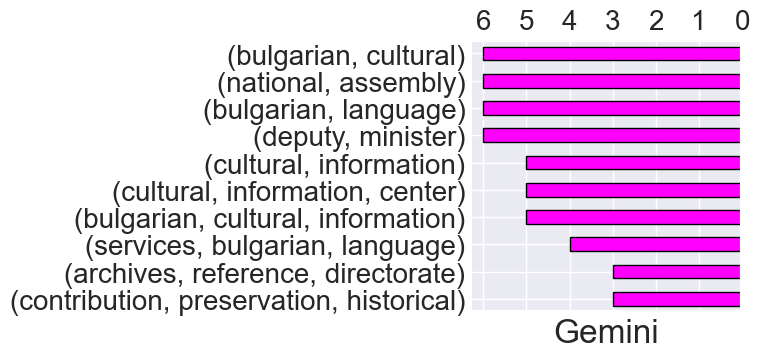

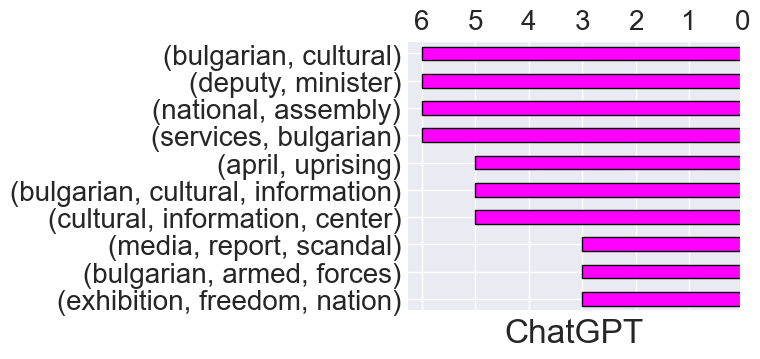

In [123]:
sentiment_bar(OUTPUT_BASE, 'results_bul/news/sentiment/graphs/sentiment_all_ru.png')

topic_df = topic('en/', OUTPUT_BASE, article_names) 
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'English')

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google')

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini')

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT')

In [124]:
#Georgian poems

texts_path = 'Data/Georgian/Vazha_ThreePoems/'

In [127]:
file_paths = ["orig/combined_vazha_poems_ge.csv", 
              "en/combined_vazha_poems_en.csv",
              "gem/combined_vazha_poems_gem.csv",
              "ggl/combined_vazha_poems_ggl.csv",
              "gpt/combined_vazha_poems_gpt.csv"]

OUTPUT_BASE = 'results/poems/sentiment/'

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)

['01_aluda_ketelauri_ge.csv', '02_host_and_guest_ge.csv', '03_the_snake_eater_ge.csv']
3
Saved: results/poems/sentiment/orig/01_aluda_ketelauri_ge.csv
Saved: results/poems/sentiment/orig/02_host_and_guest_ge.csv
Saved: results/poems/sentiment/orig/03_the_snake_eater_ge.csv
Saved: results/poems/sentiment/en/01_aluda_ketelauri_ge.csv
Saved: results/poems/sentiment/en/02_host_and_guest_ge.csv
Saved: results/poems/sentiment/en/03_the_snake_eater_ge.csv
Saved: results/poems/sentiment/ggl/01_aluda_ketelauri_ge.csv
Saved: results/poems/sentiment/ggl/02_host_and_guest_ge.csv
Saved: results/poems/sentiment/ggl/03_the_snake_eater_ge.csv
Saved: results/poems/sentiment/gem/01_aluda_ketelauri_ge.csv
Saved: results/poems/sentiment/gem/02_host_and_guest_ge.csv
Saved: results/poems/sentiment/gem/03_the_snake_eater_ge.csv
Saved: results/poems/sentiment/gpt/01_aluda_ketelauri_ge.csv
Saved: results/poems/sentiment/gpt/02_host_and_guest_ge.csv
Saved: results/poems/sentiment/gpt/03_the_snake_eater_ge.csv


  Sentiment  Count  Count  Count  Count
0     anger    154    155    168    155
1   disgust    125    130    122    127
2      fear    151    166    151    153
3       joy    240    239    239    239
4   sadness     73     73     74     74
5  surprise     76     81     75     75
6   neutral    240    238    239    239
  Sentiment  English  Google  Gemini  ChatGPT
0     anger      154     155     168      155
1   disgust      125     130     122      127
2      fear      151     166     151      153
3       joy      240     239     239      239
4   sadness       73      73      74       74
5  surprise       76      81      75       75
6   neutral      240     238     239      239
0   Models anger disgust fear  joy sadness surprise neutral
0  English   154     125  151  240      73       76     240
1   Google   155     130  166  239      73       81     238
2   Gemini   168     122  151  239      74       75     239
3  ChatGPT   155     127  153  239      74       75     239
Index(['Mode

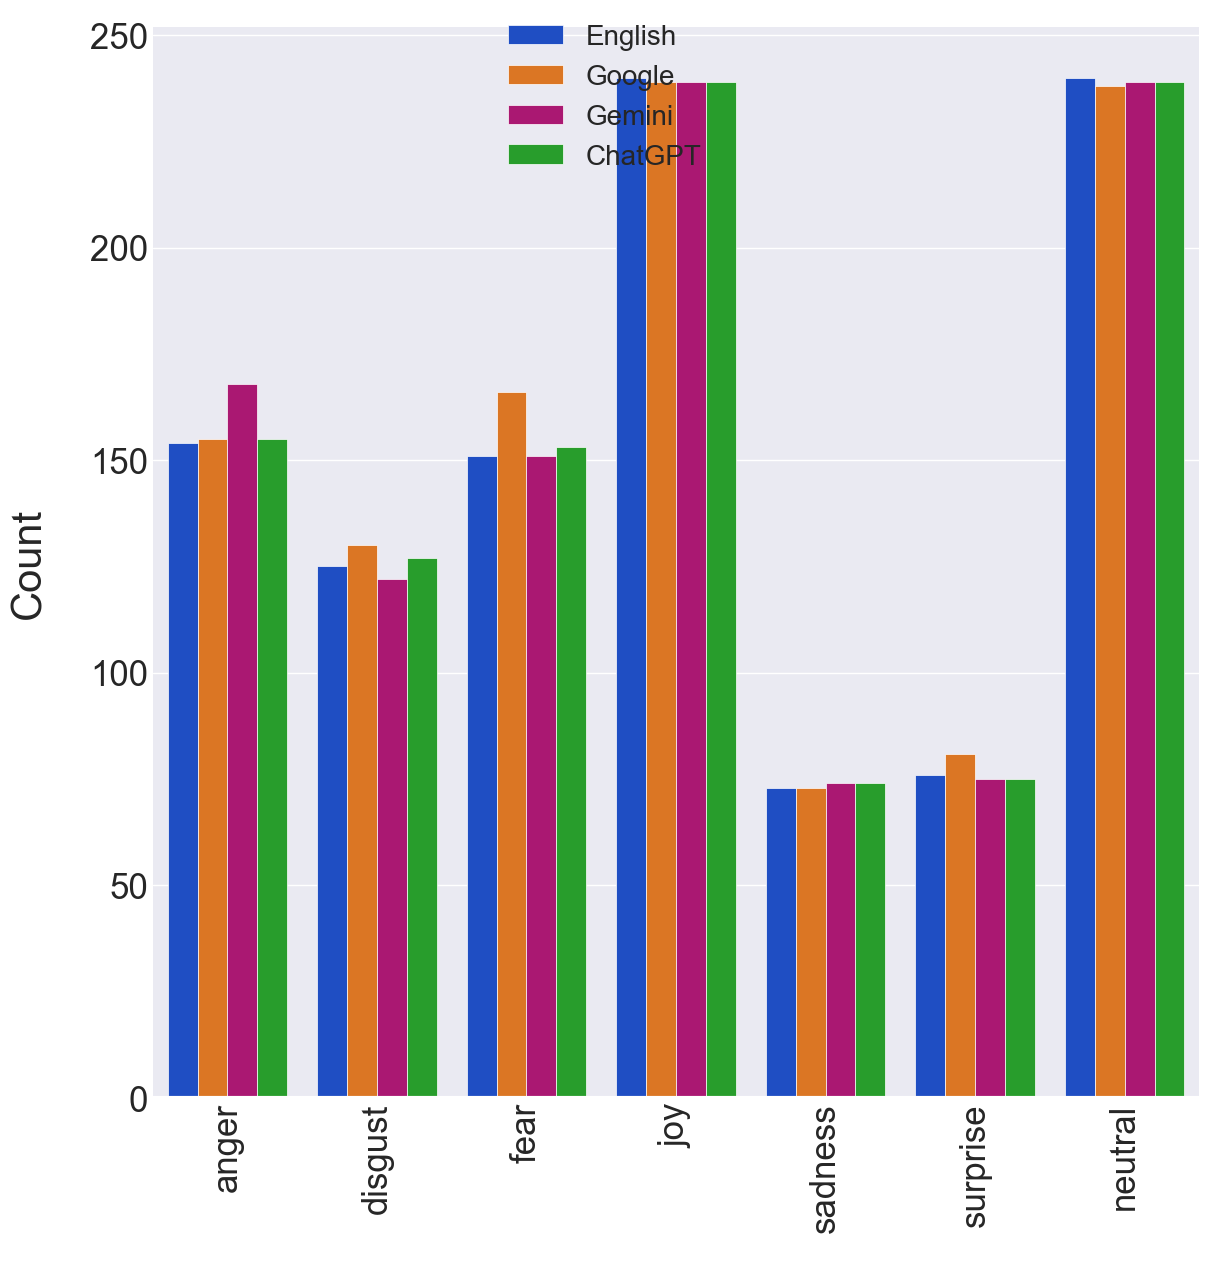

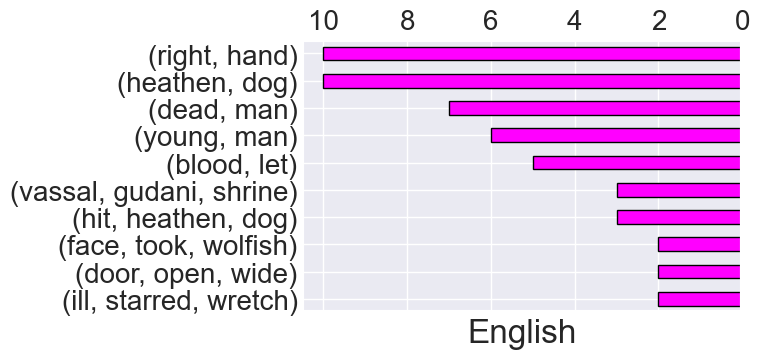

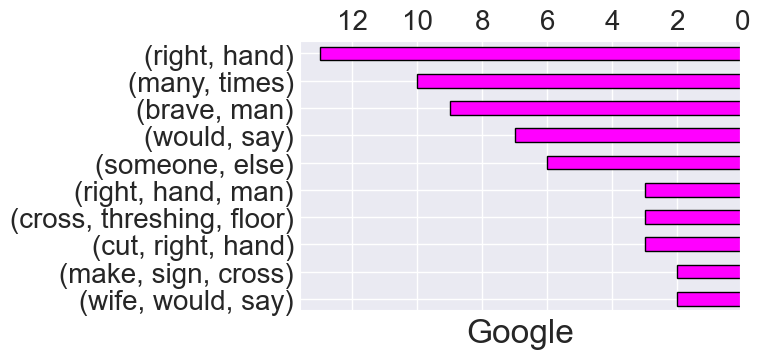

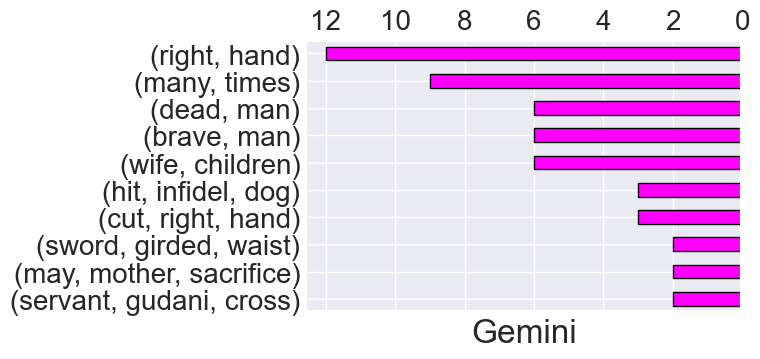

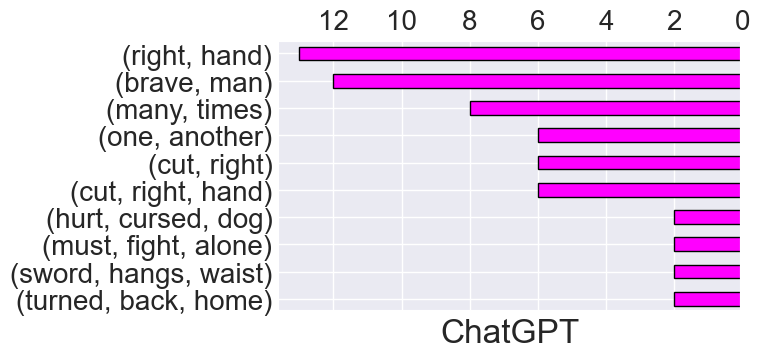

In [128]:
sentiment_bar(OUTPUT_BASE, 'results/poems/sentiment/graphs/sentiment_all_ru.png')

topic_df = topic('en/', OUTPUT_BASE, article_names) 
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'English')

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google')

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini')

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT')

In [129]:
#Bulgarian prose

texts_path = 'Data/Bulgarian/BaiGanyo/'

In [132]:
file_paths = ["orig/baiganyo_combined_master_bul.csv", 
              "en/baiganyo_combined_master_en.csv",
              "gem/baiganyo_combined_master_gem.csv",
              "ggl/baiganyo_combined_master_ggl.csv",
              "gpt/baiganyo_combined_master_gpt.csv"]

OUTPUT_BASE = 'results_bul/prose/sentiment/'

article_names, df_orig, df_en, df_ggl, df_gem, df_gpt = text_name(texts_path, file_paths)
text_df(OUTPUT_BASE, article_names, df_orig, df_en, df_ggl, df_gem, df_gpt)

['00_bai_ganyo_starts_out_for_europe_bul.csv', '01_bai_ganyo_sets_off_bul.csv', '02_bai_ganyo_at_the_opera_bul.csv', '03_bai_ganyo_at_the_baths_bul.csv', '04_bai_ganyo_in_dresden_bul.csv', '05_bai_ganyo_at_the_prague_exhibition_bul.csv', '06_bai_ganyo_at_jirecheks_bul.csv', '07_bai_ganyo_goes_visiting_bul.csv', '08_bai_ganyo_in_switzerland_bul.csv', '09_bai_ganyo_in_russia_bul.csv', '10_bai_ganyo_returns_from_europe_bul.csv', '11_bai_ganyo_does_elections_bul.csv', '12_bai_ganyo_the_journalist_bul.csv', '13_bai_ganyo_at_the_palace_bul.csv', '14_bai_ganyo_in_the_delegation_bul.csv', '15_bai_ganyo_in_the_opposition_bul.csv', '16_the_temperance_society_bul.csv', '17_letter_from_bai_ganyo_to_konstantin_velichkov_bul.csv', '18_from_the_correspondence_of_bai_ganyo_balkanski_bul.csv']
19
Saved: results_bul/prose/sentiment/orig/00_bai_ganyo_starts_out_for_europe_bul.csv
Saved: results_bul/prose/sentiment/orig/01_bai_ganyo_sets_off_bul.csv
Saved: results_bul/prose/sentiment/orig/02_bai_ganyo_at_

  Sentiment  Count  Count  Count  Count
0     anger    517    529    512    509
1   disgust    403    397    390    397
2      fear    676    667    664    654
3       joy    915    912    906    913
4   sadness    299    287    293    288
5  surprise    152    172    176    178
6   neutral    913    911    906    912
  Sentiment  English  Google  Gemini  ChatGPT
0     anger      517     529     512      509
1   disgust      403     397     390      397
2      fear      676     667     664      654
3       joy      915     912     906      913
4   sadness      299     287     293      288
5  surprise      152     172     176      178
6   neutral      913     911     906      912
0   Models anger disgust fear  joy sadness surprise neutral
0  English   517     403  676  915     299      152     913
1   Google   529     397  667  912     287      172     911
2   Gemini   512     390  664  906     293      176     906
3  ChatGPT   509     397  654  913     288      178     912
Index(['Mode

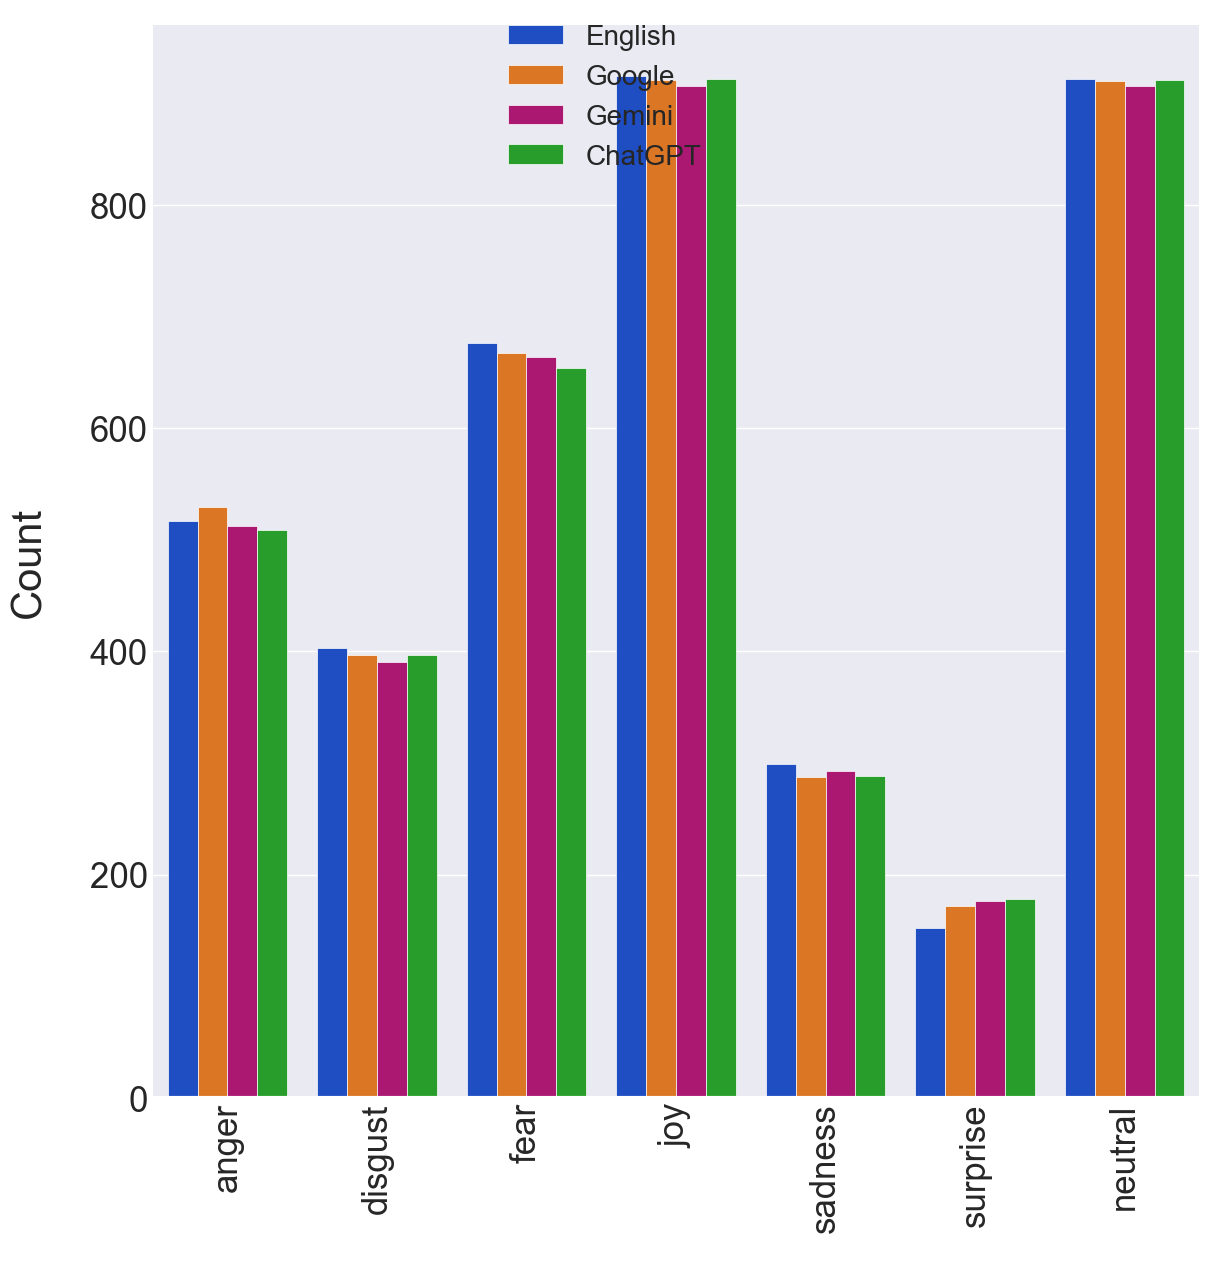

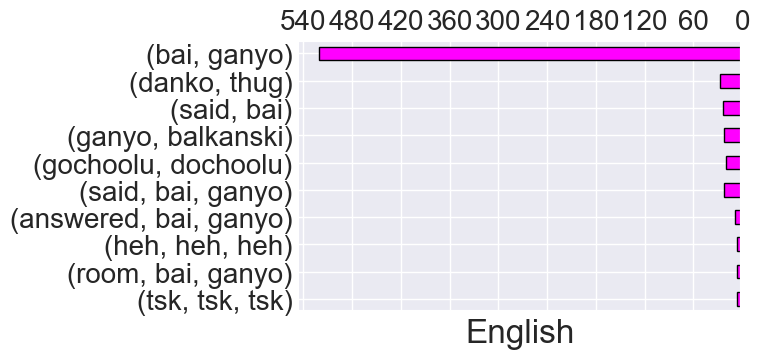

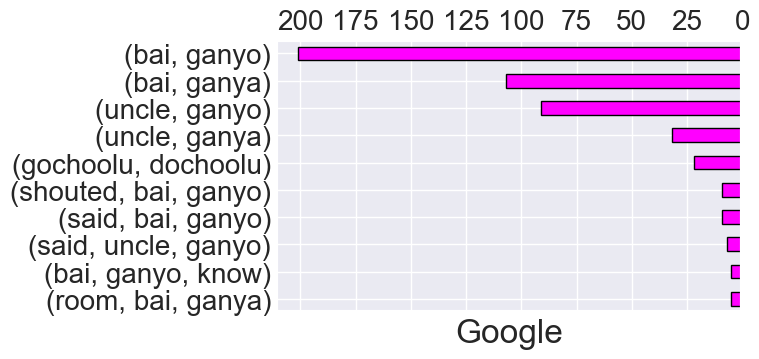

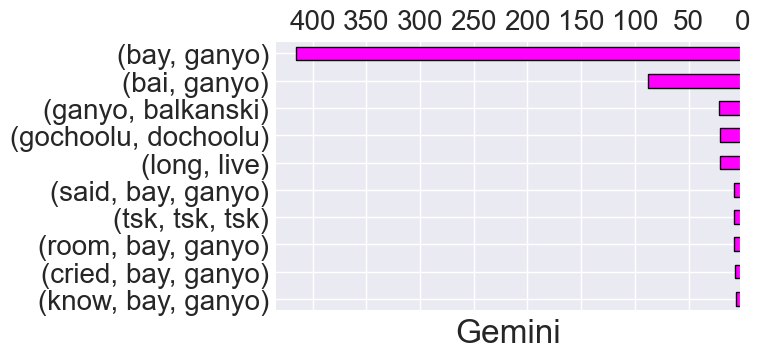

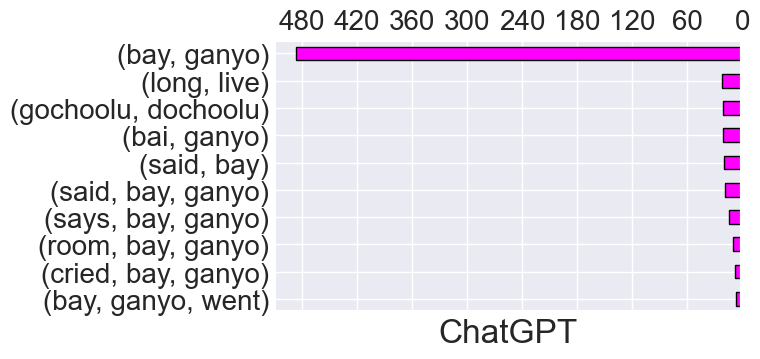

In [133]:
sentiment_bar(OUTPUT_BASE, 'results_bul/prose/sentiment/graphs/sentiment_all_ru.png')

topic_df = topic('en/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'English')

topic_df = topic('ggl/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Google')

topic_df = topic('gem/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'Gemini')

topic_df = topic('gpt/', OUTPUT_BASE, article_names)
topic_df = preprocessing(topic_df)
topic_df.head()
text = retrieve_text(topic_df)
text.split('. ')

ngrams_graphs(text, 'ChatGPT')